<h1>  
  This file compared Temperature(crawled data) with temp_sens(reported data)
</h1>

In [2]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [3]:
from src.models.data_selection.data_selector import Data_selector
import pandas as pd

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(subset=["temperature", "temp_sens"], inplace=True)

In [4]:
df = Data_selector(df).select_peaks(goodness=5)
temperature = df['temperature'].values
temp_sens = df['temp_sens'].values


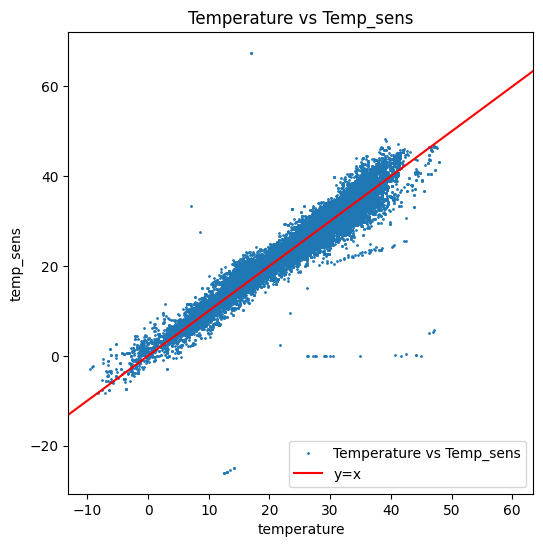

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(temperature, temp_sens, s=1, label="Temperature vs Temp_sens")
plt.axline(xy1 = (0, 0), xy2=(60, 60), color="red", label="y=x")
plt.title("Temperature vs Temp_sens")
plt.xlabel("temperature")
plt.ylabel("temp_sens")
plt.legend()
plt.show()


<h2>
    Before removing outlayer data
</h2>

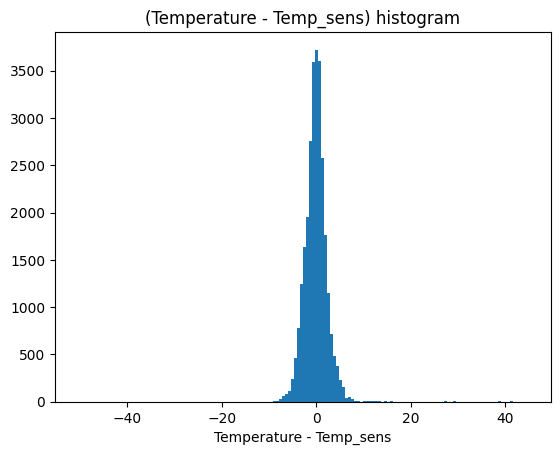

In [122]:
diff = temperature - temp_sens
plt.hist(diff,bins=150)
plt.title("(Temperature - Temp_sens) histogram")
plt.xlabel("Temperature - Temp_sens")
plt.show()

In [123]:
print(f"The mean of diff: {diff.mean():0.2f}")
print(f"The root variance of diff: {diff.std():0.2f}")
print(f"The size of data: {len(diff)}")


The mean of diff: -0.12
The root variance of diff: 2.58
The size of data: 27944


<h2>
    After removing outlayer data
</h2>

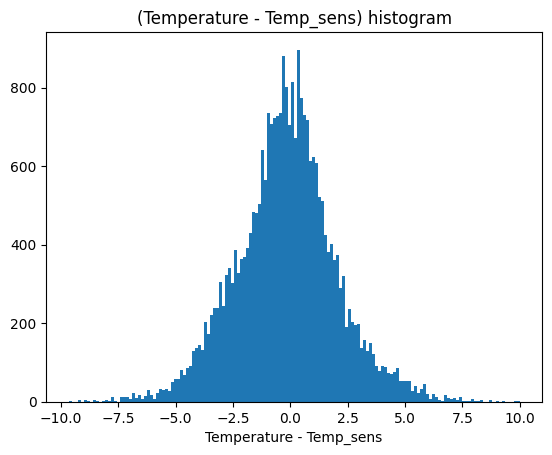

In [124]:
diff = temperature - temp_sens
diff = diff[abs(diff)<10]
plt.hist(diff,bins=150)
plt.title("(Temperature - Temp_sens) histogram")
plt.xlabel("Temperature - Temp_sens")
plt.show()

In [125]:
print(f"The mean of diff: {diff.mean():0.2f}")
print(f"The root variance of diff: {diff.std():0.2f}")
print(f"The size of data: {len(diff)}")


The mean of diff: -0.17
The root variance of diff: 2.19
The size of data: 27869
